# MONAI UNet 

Times each step of `FetalSynthGen.sample()` on a real FeTa image (256³, ~0.5 mm),
comparing **cuda** vs **cpu** for each stage. Then benchmarks the MONAI UNet
training step on the same generated batch.

Pipeline (matching `configs/data/generator/default.yaml` + fetaall real-mode):
1. Load image + segmentation from disk
2. `spatial_deform.deform()` — affine + nonlinear warp
3. `gamma()` — gamma contrast
4. `biasfield()` — bias field
5. `resampler()` + `resize_back()` — downsample/upsample
6. `noise()` — Gaussian noise
7. Full `generator.sample()` end-to-end


In [1]:
import time
import numpy as np
import torch
import nibabel as nib
import monai
from monai.transforms import Orientation, ScaleIntensity

from fetalsyngen.generator.deformation.affine_nonrigid import SpatialDeformation
from fetalsyngen.generator.augmentation.synthseg import (
    RandResample, RandBiasField, RandGamma, RandNoise,
)
from fetalsyngen.generator.model import FetalSynthGen
from fetalsyngen.generator.intensity.rand_gmm import ImageFromSeeds

print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

CUDA available: True
GPU: NVIDIA RTX 6000 Ada Generation


In [2]:
# ── Load a real image from FeTa (same dataset used in FSS training) ───────────

IMG_PATH = (
    '/media/danielaco/HDD2TB/DataDaniela/feta_2.4/'
    'sub-001/anat/sub-001_rec-mial_T2w.nii.gz'
)
SEG_PATH = (
    '/media/danielaco/HDD2TB/DataDaniela/feta_2.4/'
    'sub-001/anat/sub-001_rec-mial_dseg.nii.gz'
)

orient = Orientation(axcodes='RAS')
scaler = ScaleIntensity(minv=0, maxv=1)

def load_nii(path, dtype=torch.float32):
    arr = nib.load(path).get_fdata(dtype=np.float32)
    t = torch.from_numpy(arr).to(dtype)
    t = orient(t.unsqueeze(0)).squeeze(0)
    return t

t0 = time.perf_counter()
image_cpu = load_nii(IMG_PATH)
segm_cpu  = load_nii(SEG_PATH, dtype=torch.long)
t_load = time.perf_counter() - t0

image_cpu = scaler(image_cpu)
image_255 = (image_cpu - image_cpu.min()) / (image_cpu.max() - image_cpu.min()) * 255

print(f'Image shape: {image_cpu.shape}, dtype: {image_cpu.dtype}')
print(f'Segm  shape: {segm_cpu.shape},  dtype: {segm_cpu.dtype}')
print(f'Disk load time: {t_load*1000:.0f} ms')

/home/danielaco/miniconda3/envs/fetalsyngen/lib/python3.10/site-packages/monai/transforms/spatial/array.py:626: UserWarning: `data_array` is not of type `MetaTensor, assuming affine to be identity.
  warnings.warn("`data_array` is not of type `MetaTensor, assuming affine to be identity.")


Image shape: torch.Size([256, 256, 256]), dtype: torch.float32
Segm  shape: torch.Size([256, 256, 256]),  dtype: torch.int64
Disk load time: 392 ms


In [3]:
# ── Instantiate generator components (matching default.yaml) ──────────────────

RESOLUTION = [0.5, 0.5, 0.5]   # FeTa native resolution

def make_components(device):
    spatial_deform = SpatialDeformation(
        max_rotation=20, max_shear=0.02, max_scaling=0.1, prob=0.9,
        nonlinear_transform=True, nonlin_scale_min=0.03,
        nonlin_scale_max=0.06, nonlin_std_max=4, flip_prb=0.5,
        device=device,
    )
    resampler  = RandResample(prob=0.9, min_resolution=0.75, max_resolution=1.5)
    bias_field = RandBiasField(prob=0.9, scale_min=0.004, scale_max=0.02,
                               std_min=0.01, std_max=0.3)
    gamma      = RandGamma(prob=0.9, gamma_std=0.1)
    noise      = RandNoise(prob=0.9, std_min=5, std_max=15)
    return spatial_deform, resampler, bias_field, gamma, noise

comps_cuda = make_components('cuda')
comps_cpu  = make_components('cpu')
print('Components ready.')

Components ready.


In [4]:
# ── Timing helper ──────────────────────────────────────────────────────────────

def timeit(fn, n=5, device='cuda'):
    if device == 'cuda':
        torch.cuda.synchronize()
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        if device == 'cuda':
            torch.cuda.synchronize()
        times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times), np.std(times)

In [5]:
# ── 1. Spatial deformation ────────────────────────────────────────────────────
results = {}
for device, (spatial_deform, resampler, bias_field, gamma, noise) in [
    ('cuda', comps_cuda), ('cpu', comps_cpu)
]:
    img = image_255.to(device)
    seg = segm_cpu.to(device)
    sd_ref = spatial_deform
    mu, sd = timeit(lambda: sd_ref.deform(image=img, segmentation=seg, output=img), device=device)
    results[f'spatial_deform_{device}'] = (mu, sd)
    print(f'spatial_deform [{device}]: {mu:.0f} ± {sd:.0f} ms')

spatial_deform [cuda]: 312 ± 79 ms
spatial_deform [cpu]: 6458 ± 106 ms


In [6]:
# ── 2. Gamma ──────────────────────────────────────────────────────────────────
for device, (spatial_deform, resampler, bias_field, gamma, noise) in [
    ('cuda', comps_cuda), ('cpu', comps_cpu)
]:
    img = image_255.to(device)
    gam_ref = gamma
    mu, sd = timeit(lambda: gam_ref(img, device), device=device)
    results[f'gamma_{device}'] = (mu, sd)
    print(f'gamma [{device}]: {mu:.0f} ± {sd:.0f} ms')

gamma [cuda]: 3 ± 5 ms
gamma [cpu]: 95 ± 16 ms


In [7]:
# ── 3. Bias field ─────────────────────────────────────────────────────────────
for device, (spatial_deform, resampler, bias_field, gamma, noise) in [
    ('cuda', comps_cuda), ('cpu', comps_cpu)
]:
    img = image_255.to(device)
    bf_ref = bias_field
    mu, sd = timeit(lambda: bf_ref(img, device), device=device)
    results[f'bias_field_{device}'] = (mu, sd)
    print(f'bias_field [{device}]: {mu:.0f} ± {sd:.0f} ms')

bias_field [cuda]: 37 ± 45 ms
bias_field [cpu]: 369 ± 8 ms


In [8]:
# ── 4. Resample down + up ─────────────────────────────────────────────────────
for device, (spatial_deform, resampler, bias_field, gamma, noise) in [
    ('cuda', comps_cuda), ('cpu', comps_cpu)
]:
    img = image_255.to(device)
    res = np.array(RESOLUTION)
    res_ref = resampler
    def _resample():
        out, factors, _ = res_ref(img, res, device)
        res_ref.resize_back(out, factors)
    mu, sd = timeit(_resample, device=device)
    results[f'resample_{device}'] = (mu, sd)
    print(f'resample down+up [{device}]: {mu:.0f} ± {sd:.0f} ms')

resample down+up [cuda]: 147 ± 60 ms
resample down+up [cpu]: 1143 ± 53 ms


In [9]:
# ── 5. Noise ──────────────────────────────────────────────────────────────────
for device, (spatial_deform, resampler, bias_field, gamma, noise) in [
    ('cuda', comps_cuda), ('cpu', comps_cpu)
]:
    img = image_255.to(device)
    noise_ref = noise
    mu, sd = timeit(lambda: noise_ref(img, device), device=device)
    results[f'noise_{device}'] = (mu, sd)
    print(f'noise [{device}]: {mu:.0f} ± {sd:.0f} ms')

noise [cuda]: 1 ± 0 ms
noise [cpu]: 184 ± 92 ms


In [10]:
# ── 6. Full generator.sample() end-to-end ─────────────────────────────────────
# seed_labels unused in real mode (seeds=None → image used as intensity prior)
SEED_LABELS        = [0, 1, 2, 3, 4, 5, 6, 7]
GENERATION_CLASSES = [0, 1, 2, 3, 1, 4, 2, 5]

intensity_gen = ImageFromSeeds(
    min_subclusters=1, max_subclusters=6,
    seed_labels=SEED_LABELS, generation_classes=GENERATION_CLASSES,
)

for device, (spatial_deform, resampler, bias_field, gamma, noise) in [
    ('cuda', comps_cuda), ('cpu', comps_cpu)
]:
    gen = FetalSynthGen(
        shape=[256, 256, 256], resolution=RESOLUTION, device=device,
        intensity_generator=intensity_gen, spatial_deform=spatial_deform,
        resampler=resampler, bias_field=bias_field, gamma=gamma, noise=noise,
    )
    img, seg, gen_ref = image_255.clone(), segm_cpu.clone(), gen
    mu, sd = timeit(
        lambda: gen_ref.sample(image=img, segmentation=seg, seeds=None),
        n=5, device=device,
    )
    results[f'full_sample_{device}'] = (mu, sd)
    print(f'full generator.sample() [{device}]: {mu:.0f} ± {sd:.0f} ms')

full generator.sample() [cuda]: 820 ± 10 ms
full generator.sample() [cpu]: 7849 ± 179 ms


In [11]:
# ── Summary table ─────────────────────────────────────────────────────────────
import pandas as pd

steps = ['spatial_deform', 'gamma', 'bias_field', 'resample', 'noise', 'full_sample']
rows = []
for step in steps:
    mu_cuda, sd_cuda = results.get(f'{step}_cuda', (float('nan'), float('nan')))
    mu_cpu,  sd_cpu  = results.get(f'{step}_cpu',  (float('nan'), float('nan')))
    speedup = mu_cpu / mu_cuda if mu_cuda > 0 else float('nan')
    rows.append({'step': step,
                 'cuda (ms)': f'{mu_cuda:.0f} ± {sd_cuda:.0f}',
                 'cpu  (ms)': f'{mu_cpu:.0f} ± {sd_cpu:.0f}',
                 'cuda speedup': f'{speedup:.1f}x'})

df = pd.DataFrame(rows).set_index('step')
print(df.to_string())
print(f'\nDisk load: {t_load*1000:.0f} ms (one-time per sample)')

               cuda (ms)   cpu  (ms) cuda speedup
step                                             
spatial_deform  312 ± 79  6458 ± 106        20.7x
gamma              3 ± 5     95 ± 16        32.7x
bias_field       37 ± 45     369 ± 8         9.9x
resample        147 ± 60   1143 ± 53         7.8x
noise              1 ± 0    184 ± 92       212.5x
full_sample     820 ± 10  7849 ± 179         9.6x

Disk load: 392 ms (one-time per sample)


## Visualize augmentation outputs

Mid-slices (axial / coronal / sagittal) for: original, after spatial deformation, after full augmentation.

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

device = 'cuda'
spatial_deform, resampler, bias_field, gamma, noise = comps_cuda

img = image_255.to(device)
seg = segm_cpu.to(device)

orig = (img / 255.0).cpu()

img_def, seg_def, _, _ = spatial_deform.deform(image=img, segmentation=seg, output=img)
after_deform = (img_def / 255.0).clamp(0, 1).cpu()
seg_def_cpu  = seg_def.cpu()

out, _ = gamma(img_def, device)
out, _ = bias_field(out, device)
out, factors, _ = resampler(out, np.array(RESOLUTION), device)
out, _ = noise(out, device)
out = resampler.resize_back(out, factors)
after_augment = (out / out.max()).clamp(0, 1).cpu()

print('Captured: original, after spatial deform, after full augment')

Captured: original, after spatial deform, after full augment


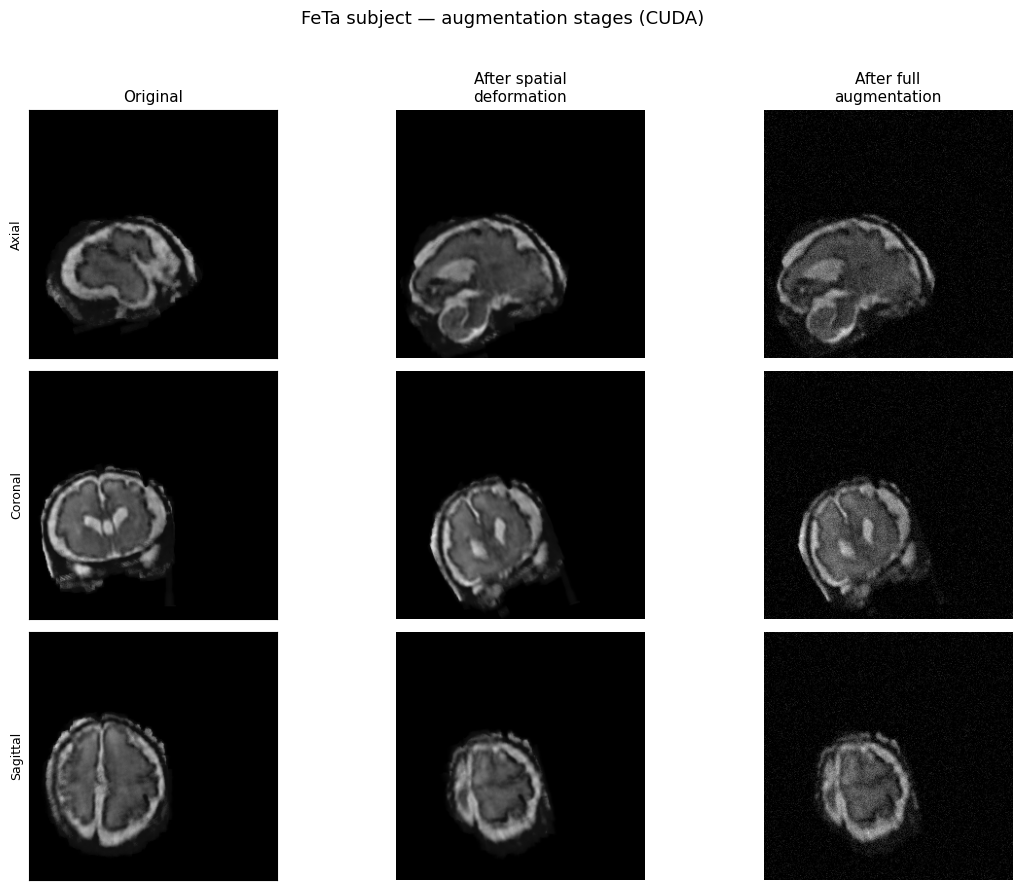

In [13]:
def mid(vol):
    v = vol.squeeze()
    h, w, d = v.shape
    return v[h//2, :, :], v[:, w//2, :], v[:, :, d//2]

stages = [
    ('Original', orig),
    ('After spatial\ndeformation', after_deform),
    ('After full\naugmentation', after_augment),
]
plane_labels = ['Axial', 'Coronal', 'Sagittal']

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.05, wspace=0.05)
for col, (title, vol) in enumerate(stages):
    for row, (sl, plane) in enumerate(zip(mid(vol), plane_labels)):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(sl.numpy().T, cmap='gray', origin='lower', vmin=0, vmax=1)
        ax.axis('off')
        if row == 0: ax.set_title(title, fontsize=11, pad=6)
        if col == 0:
            ax.set_ylabel(plane, fontsize=9)
            ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('FeTa subject — augmentation stages (CUDA)', fontsize=13, y=0.98)
plt.show()

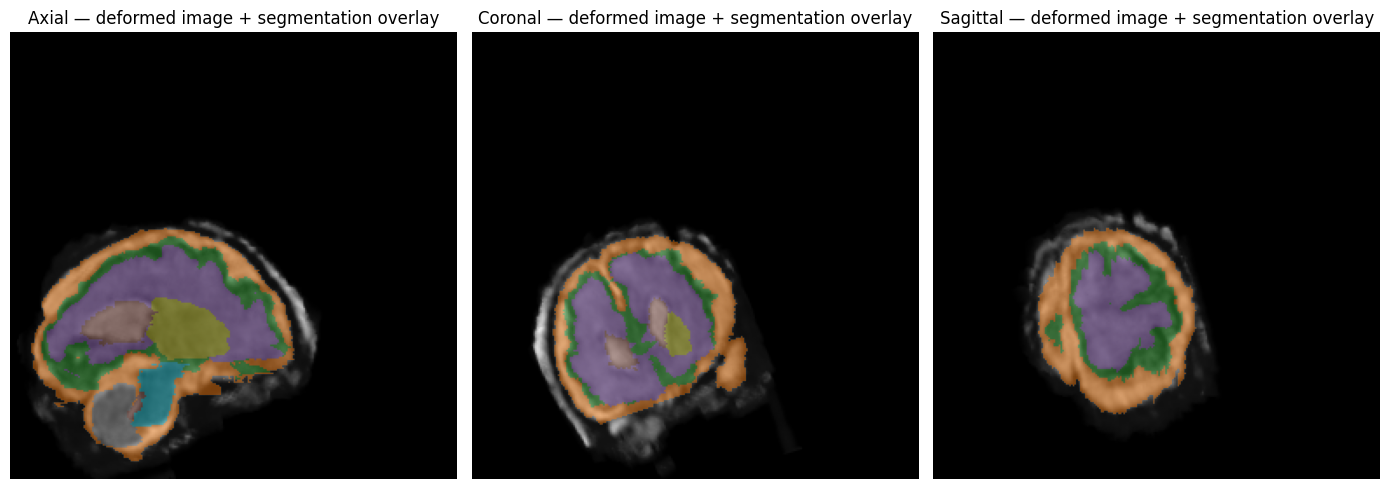

In [14]:
# ── Segmentation overlay on deformed image ─────────────────────────────────────
cmap_seg = plt.colormaps.get_cmap('tab10').resampled(int(seg_def_cpu.max().item()) + 1)
v = after_deform.squeeze()
s = seg_def_cpu.squeeze().float()
h, w, d = v.shape

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (img_sl, seg_sl, label) in zip(axes, [
    (v[h//2].numpy().T,       s[h//2].numpy().T,       'Axial'),
    (v[:, w//2].numpy().T,    s[:, w//2].numpy().T,    'Coronal'),
    (v[:, :, d//2].numpy().T, s[:, :, d//2].numpy().T, 'Sagittal'),
]):
    ax.imshow(img_sl, cmap='gray', origin='lower', vmin=0, vmax=1)
    seg_rgba = cmap_seg(seg_sl / cmap_seg.N)
    seg_rgba[..., 3] = np.where(seg_sl > 0, 0.45, 0.0)
    ax.imshow(seg_rgba, origin='lower')
    ax.set_title(f'{label} — deformed image + segmentation overlay')
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## Training step benchmark

Instantiates MONAI UNet with exact hyperparameters from `configs/model/segmentor.yaml`
and times each sub-step of a training iteration using the **real FeTa subject** augmented above.

| sub-step | what happens |
|---|---|
| forward | UNet encoder-decoder |
| loss | `DiceCELoss` (Dice + CE combined) |
| backward | gradient computation through the UNet |
| optimizer | Adam parameter update |
| **full_step** | all of the above combined |

In [15]:
# ── GPU memory check ───────────────────────────────────────────────────────────
free_mem  = torch.cuda.mem_get_info()[0] / 1e9
total_mem = torch.cuda.mem_get_info()[1] / 1e9
print(f'GPU free: {free_mem:.1f} GB / {total_mem:.1f} GB')
if free_mem < 6:
    raise RuntimeError(
        f'Only {free_mem:.1f} GB free — stop the running training before '
        'benchmarking the model.'
    )
if free_mem < 10:
    print(f'Warning: only {free_mem:.1f} GB free — model may OOM. Continuing anyway.')
torch.cuda.empty_cache()

import torch.nn.functional as F
from torch.amp import autocast, GradScaler

# ── Model — exact params from configs/model/segmentor.yaml + fetaall_real.yaml ─
DEVICE      = 'cuda'
BATCH_SIZE  = 2     # fetaall_real.yaml: batch_size: 2 # trying 2
NUM_CLASSES = 8     # fetaall_real.yaml: out_channels: 8

net = monai.networks.nets.UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=NUM_CLASSES,
    channels=(32, 64, 128, 256, 512),
    strides=(2, 2, 2, 2),
    kernel_size=3,
    up_kernel_size=3,
    num_res_units=2,
    act='leakyrelu',
    norm='instance',
    dropout=0,
).to(DEVICE)

criterion   = monai.losses.DiceCELoss(to_onehot_y=True, include_background=False, softmax=True)
optimizer   = torch.optim.Adam(net.parameters(), lr=1e-4)
grad_scaler = GradScaler('cuda')

print(f'Model parameters: {sum(p.numel() for p in net.parameters())/1e6:.1f}M')

# ── Real batch from the FeTa subject augmented above ──────────────────────────
images = after_augment.unsqueeze(0).unsqueeze(0).repeat(BATCH_SIZE, 1, 1, 1, 1).to(DEVICE)
labels = seg_def_cpu.clamp(0, NUM_CLASSES - 1).unsqueeze(0).unsqueeze(0).repeat(BATCH_SIZE, 1, 1, 1, 1).to(DEVICE)

print(f'images: {tuple(images.shape)}, dtype: {images.dtype}')
print(f'labels: {tuple(labels.shape)}, unique values: {labels.unique().tolist()}')

GPU free: 44.2 GB / 50.9 GB
Model parameters: 19.2M
images: (2, 1, 256, 256, 256), dtype: torch.float32
labels: (2, 1, 256, 256, 256), unique values: [0, 1, 2, 3, 4, 5, 6, 7]


In [16]:
# ── Time each sub-step individually ───────────────────────────────────────────
N = 10
step_times = {}

# 1. Forward
def _forward():
    with autocast('cuda'):
        net(images)
mu, sd = timeit(_forward, n=N)
step_times['forward'] = (mu, sd)
print(f'forward:       {mu:6.0f} ± {sd:.0f} ms')

# pre-compute logits for sub-step benchmarks
with autocast('cuda'):
    logits = net(images).detach()

# 2. Loss (DiceCELoss — combines Dice + CE in one pass)
mu, sd = timeit(lambda: criterion(logits, labels.float()), n=N)
step_times['loss'] = (mu, sd)
print(f'loss:          {mu:6.0f} ± {sd:.0f} ms')

# 3. Backward
def _backward():
    optimizer.zero_grad(set_to_none=True)
    with autocast('cuda'):
        out  = net(images)
        loss = criterion(out, labels.float())
    grad_scaler.scale(loss).backward()
mu, sd = timeit(_backward, n=N)
step_times['backward'] = (mu, sd)
print(f'backward:      {mu:6.0f} ± {sd:.0f} ms')

# 4. Optimizer step
def _opt():
    grad_scaler.step(optimizer)
    grad_scaler.update()
mu, sd = timeit(_opt, n=N)
step_times['optimizer'] = (mu, sd)
print(f'optimizer:     {mu:6.0f} ± {sd:.0f} ms')

forward:          104 ± 35 ms
loss:              13 ± 5 ms
backward:         267 ± 15 ms
optimizer:          7 ± 13 ms


In [17]:
# ── Full training step end-to-end ──────────────────────────────────────────────
def _full_step():
    optimizer.zero_grad(set_to_none=True)
    with autocast('cuda'):
        out  = net(images)
        loss = criterion(out, labels.float())
    grad_scaler.scale(loss).backward()
    grad_scaler.step(optimizer)
    grad_scaler.update()

mu, sd = timeit(_full_step, n=N)
step_times['full_step'] = (mu, sd)
print(f'full_step:     {mu:6.0f} ± {sd:.0f} ms')

full_step:        265 ± 1 ms


In [18]:
# ── Summary: training step breakdown + data/compute ratio ─────────────────────
full_ms   = step_times['full_step'][0]
data_cuda = results['full_sample_cuda'][0]
data_cpu  = results['full_sample_cpu'][0]

print('Training step breakdown')
print('=' * 48)
for name, (mu, sd) in step_times.items():
    pct = mu / full_ms * 100 if name != 'full_step' else 100.0
    print(f'  {name:<14} {mu:6.0f} ± {sd:3.0f} ms   ({pct:.0f}% of step)')

print()
print('Data loading vs training step')
print('=' * 48)
print(f'  generator.sample [cuda]:  {data_cuda:6.0f} ms')
print(f'  generator.sample [cpu]:   {data_cpu:6.0f} ms')
print(f'  training step:            {full_ms:6.0f} ms')
print()
ratio = data_cuda / full_ms
print(f'  GPU data/compute ratio:   {ratio:.2f}x')
if ratio > 1:
    print(f'  → Data loading takes {ratio:.1f}x longer than training.')
else:
    print('  → Training step is slower than data loading: compute-bound.')

Training step breakdown
  forward           104 ±  35 ms   (39% of step)
  loss               13 ±   5 ms   (5% of step)
  backward          267 ±  15 ms   (101% of step)
  optimizer           7 ±  13 ms   (2% of step)
  full_step         265 ±   1 ms   (100% of step)

Data loading vs training step
  generator.sample [cuda]:     820 ms
  generator.sample [cpu]:     7849 ms
  training step:               265 ms

  GPU data/compute ratio:   3.10x
  → Data loading takes 3.1x longer than training.


---
## Full per-iteration breakdown — supervisor summary

Real wall-clock breakdown of **one training iteration** under the current setup:

| setting | value |
|---|---|
| `num_workers` | 0 (sequential: disk → generator → train step) |
| `batch_size` | 1 |
| volume size | 256³ voxels, ~0.5 mm isotropic |
| storage | HDD (`/media/danielaco/HDD2TB/`) |
| precision | fp16-mixed (AMP) |

In [19]:
# ── Disk I/O: time loading several FeTa subjects to get a robust average ──────
import os, glob

FETA_ROOT = '/media/danielaco/HDD2TB/DataDaniela/feta_2.4/'
img_glob  = sorted(glob.glob(os.path.join(FETA_ROOT, 'sub-*/anat/*_T2w.nii.gz')))[:6]
seg_glob  = sorted(glob.glob(os.path.join(FETA_ROOT, 'sub-*/anat/*_dseg.nii.gz')))[:6]

io_times = []
for ip, sp in zip(img_glob, seg_glob):
    t0 = time.perf_counter()
    _ = nib.load(ip).get_fdata(dtype=np.float32)
    _ = nib.load(sp).get_fdata(dtype=np.float32)
    io_times.append((time.perf_counter() - t0) * 1000)
    print(f'  {os.path.basename(ip)[:50]:50s}  {io_times[-1]:.0f} ms')

mean_io = float(np.mean(io_times))
std_io  = float(np.std(io_times))
print()
print(f'Disk I/O (image + seg, HDD):  {mean_io:.0f} ± {std_io:.0f} ms per sample')
print(f'For batch_size=2:             {mean_io * 2:.0f} ms total')

  sub-001_rec-mial_T2w.nii.gz                         344 ms
  sub-002_rec-mial_T2w.nii.gz                         337 ms
  sub-003_rec-mial_T2w.nii.gz                         331 ms
  sub-004_rec-mial_T2w.nii.gz                         324 ms
  sub-005_rec-mial_T2w.nii.gz                         338 ms
  sub-006_rec-mial_T2w.nii.gz                         332 ms

Disk I/O (image + seg, HDD):  334 ± 6 ms per sample
For batch_size=2:             669 ms total


In [20]:
# ── Reconstruct full per-iteration timing ─────────────────────────────────────
batch_size    = BATCH_SIZE
disk_ms       = mean_io
gen_ms        = results['full_sample_cuda'][0]
train_ms      = step_times['full_step'][0]

disk_total_ms = disk_ms  * batch_size
gen_total_ms  = gen_ms   * batch_size
total_ms      = disk_total_ms + gen_total_ms + train_ms
its_per_sec   = 1000.0 / total_ms

ssd_disk_ms   = 100.0
ssd_total_ms  = ssd_disk_ms * batch_size + gen_total_ms + train_ms
ssd_its       = 1000.0 / ssd_total_ms

W = 52
print('=' * W)
print(f'  {"Component":<30}  {"ms":>6}  {"% iter":>6}')
print('=' * W)
print(f'  {"Disk I/O (x2 samples, HDD)":<30}  {disk_total_ms:>6.0f}  {disk_total_ms/total_ms*100:>5.1f}%')
print(f'  {"GPU generator (x2 samples)":<30}  {gen_total_ms:>6.0f}  {gen_total_ms/total_ms*100:>5.1f}%')
print(f'    spatial deform x1         {results["spatial_deform_cuda"][0]:>6.0f}')
print(f'  {"Training step":<30}  {train_ms:>6.0f}  {train_ms/total_ms*100:>5.1f}%')
print(f'    forward pass              {step_times["forward"][0]:>6.0f}')
print(f'    backward pass             {step_times["backward"][0]:>6.0f}')
print('-' * W)
print(f'  {"TOTAL (HDD)":<30}  {total_ms:>6.0f}  100.0%')
print(f'  {"Throughput (HDD)":<30}  {its_per_sec:>6.2f}  it/s')
print()

  Component                           ms  % iter
  Disk I/O (x2 samples, HDD)         669   26.0%
  GPU generator (x2 samples)        1640   63.7%
    spatial deform x1            312
  Training step                      265   10.3%
    forward pass                 104
    backward pass                267
----------------------------------------------------
  TOTAL (HDD)                       2574  100.0%
  Throughput (HDD)                  0.39  it/s

  TOTAL (SSD what-if)               2105
  Throughput (SSD)                  0.48  it/s


In [21]:
# ── Detailed augmentation stage table ─────────────────────────────────────────
import pandas as pd

aug_steps = ['spatial_deform', 'gamma', 'bias_field', 'resample', 'noise', 'full_sample']
rows = []
for step in aug_steps:
    mu_c, sd_c = results.get(f'{step}_cuda', (float('nan'), float('nan')))
    mu_p, sd_p = results.get(f'{step}_cpu',  (float('nan'), float('nan')))
    speedup    = mu_p / mu_c if mu_c > 0 else float('nan')
    rows.append({
        'Augmentation stage': step,
        'CUDA (ms)':    f'{mu_c:.0f} ± {sd_c:.0f}',
        'CPU  (ms)':    f'{mu_p:.0f} ± {sd_p:.0f}',
        'CUDA speedup': f'{speedup:.1f}x',
    })
df_aug = pd.DataFrame(rows).set_index('Augmentation stage')
print('Augmentation stage timings (single sample, 256³ @ 0.5 mm):')
print(df_aug.to_string())
print()

train_steps = ['forward', 'loss', 'backward', 'optimizer', 'full_step']
rows2 = []
full_ms_ = step_times['full_step'][0]
for s in train_steps:
    mu, sd = step_times[s]
    pct = mu / full_ms_ * 100 if s != 'full_step' else 100.0
    rows2.append({'Training sub-step': s,
                  'Mean (ms)': f'{mu:.0f}',
                  'Std (ms)':  f'{sd:.0f}',
                  '% of step': f'{pct:.0f}%'})
df_train = pd.DataFrame(rows2).set_index('Training sub-step')
print('Training step sub-timings (batch=2, 256³, fp16-mixed):')
print(df_train.to_string())

Augmentation stage timings (single sample, 256³ @ 0.5 mm):
                   CUDA (ms)   CPU  (ms) CUDA speedup
Augmentation stage                                   
spatial_deform      312 ± 79  6458 ± 106        20.7x
gamma                  3 ± 5     95 ± 16        32.7x
bias_field           37 ± 45     369 ± 8         9.9x
resample            147 ± 60   1143 ± 53         7.8x
noise                  1 ± 0    184 ± 92       212.5x
full_sample         820 ± 10  7849 ± 179         9.6x

Training step sub-timings (batch=2, 256³, fp16-mixed):
                  Mean (ms) Std (ms) % of step
Training sub-step                             
forward                 104       35       39%
loss                     13        5        5%
backward                267       15      101%
optimizer                 7       13        2%
full_step               265        1      100%
